In [1]:
from pathlib import Path
from slc.utils import setup_notebook

setup_notebook(
    device = 0,
    tmp_dir=Path("/local/scratch/carlyn.1/tmp"),
    hf_cache_dir=Path("/local/scratch/carlyn.1/hf_cache"),
)

CUB_ROOT_DIR = Path("/local/scratch/cv_datasets/CUB_200_2011")

In [2]:
import torch

from slc.models import CUBDINOv3RecognitionModel

classifier = CUBDINOv3RecognitionModel(class_num=200).cuda()
classifier.eval()

classifier.classifier.load_state_dict(torch.load("../data/weights/cub_dino_classifier.pt"))

/home/carlyn.1/code/simple-localized-counterfactuals/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/carlyn.1/code/simple-localized-counterfactuals/.venv/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2274: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/carlyn.1/code/simple-localized-counterfactuals/.venv/lib/python3.12/site-packages/pydantic/_inter

<All keys matched successfully>

In [3]:
from slc.datasets import CUBDatasetInterface
from slc.constants import DatasetNames

dataset_root = CUB_ROOT_DIR
dset = CUBDatasetInterface(root=dataset_root)

156


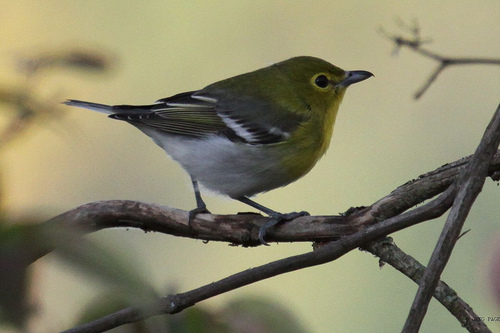

In [4]:
train_dset = dset.get_torch_dataset(phase="test", class_idxs=[156]) # 150, 145

IDX = 16 # 20, 10

img = train_dset[IDX][0]
lbl = train_dset[IDX][1]
print(lbl)
img

In [5]:
src_label = lbl
tgt_label = 155

In [6]:
from slc.models import SDVAEPipeline
import torchvision.transforms.functional as F
from diffusers.utils import make_image_grid

vae = SDVAEPipeline().cuda()

In [7]:
import torch
from saev.nn import SparseAutoencoderConfig, SparseAutoencoder

cfg = SparseAutoencoderConfig(
    d_model=768,
    d_sae=768 * 8,
    normalize_w_dec=True,
)

sae = SparseAutoencoder(cfg=cfg).cuda()
sae.eval()

sae_path = "../data/weights/cub_dino_sae.pt"
sae.load_state_dict(torch.load(sae_path))

<All keys matched successfully>

In [8]:
from dataclasses import dataclass
from typing import Any

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms.functional as F
from PIL import Image
from scipy import ndimage
from tqdm import tqdm

from slc.pipelines import SAELatentEditPipeline
from slc.experiments.configs.cfg_2 import sae_configs

sae_configs.verbose = True
sae_configs.gaussian_blur_sigma = 4
sae_configs.mask_threshold = 0.7
sae_configs.sparsity_lambda = 0.2
sae_configs.early_stop_threshold = 0.1
sae_configs.peturb_strength = .1
sae_configs.lr = 0.1
edit_pipeline = SAELatentEditPipeline(classifier, vae, sae_configs, sae)

Creating Counterfactual:   9%|▉         | 46/500 [00:09<01:28,  5.11it/s, class_loss=-2.99, sparsity_loss=0.0741, predicted_class=155, src_conf=0.0142, tgt_conf=0.11]   


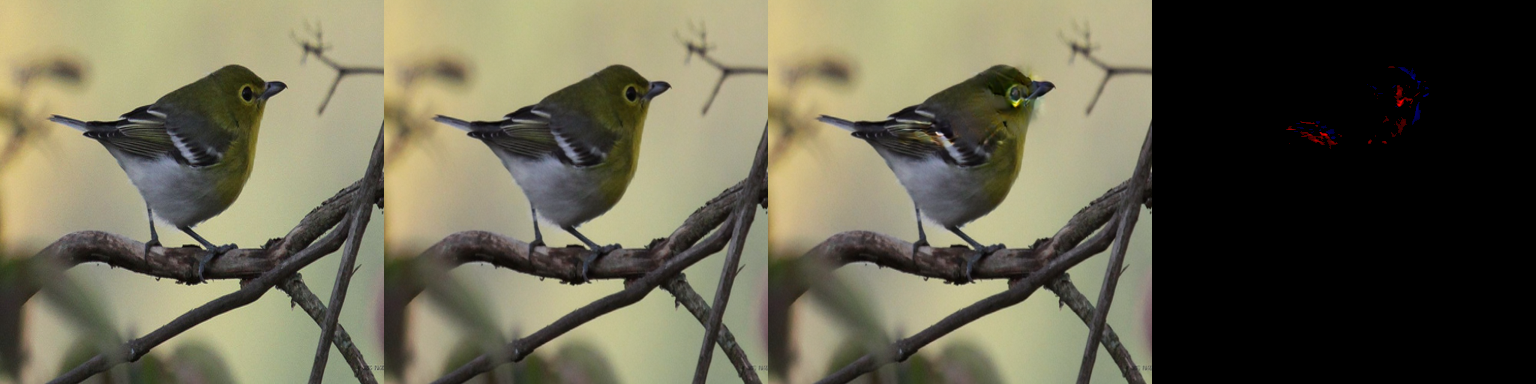

In [9]:
from diffusers.utils import make_image_grid

from slc.vis import create_diff_image
from slc.pipelines import EditPipelineOutput

edit_output: EditPipelineOutput = edit_pipeline(img, src_label=src_label, tgt_label=tgt_label)

recon = edit_output.recon_image.resize((384, 384))
edit_image = edit_output.edit_image.resize((384, 384))
diff_img = create_diff_image(edit_image, recon, threshold=0.2)

make_image_grid(
    [
        img.resize((384, 384)), 
        recon,
        edit_image,
        diff_img
    ],
    rows=1,
    cols=4
)

In [10]:
import torch
output = classifier(classifier.preprocess_tensor_image(F.to_tensor(edit_output.edit_image)).unsqueeze(0).cuda())
torch.max(output, 1)

torch.return_types.max(
values=tensor([29.6781], device='cuda:0', grad_fn=<MaxBackward0>),
indices=tensor([155], device='cuda:0'))

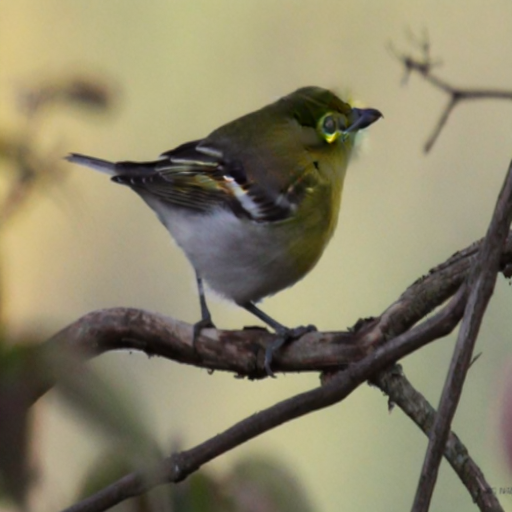

In [11]:
import torchvision.transforms.functional as F
er = vae(vae.preprocess_image(F.to_tensor(edit_image)).unsqueeze(0).cuda())
F.to_pil_image(er[0])

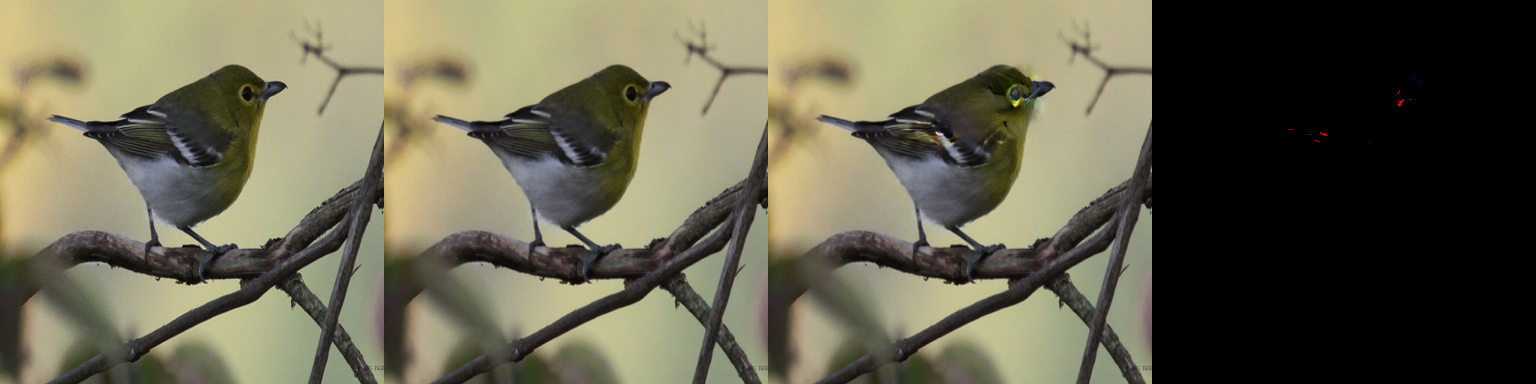

In [12]:
diff_img = create_diff_image(edit_image, recon, threshold=0.5)

make_image_grid(
    [
        img.resize((384, 384)), 
        recon,
        edit_image,
        diff_img
    ],
    rows=1,
    cols=4
)

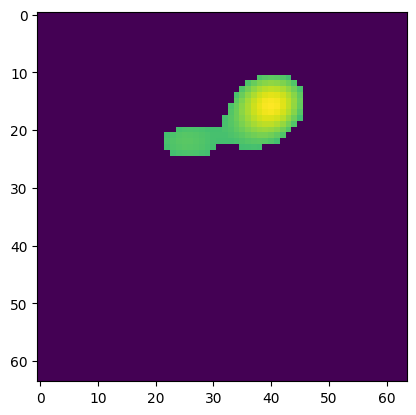

In [13]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(edit_output.thresholded_mask[0, 0].cpu().numpy())
plt.show()

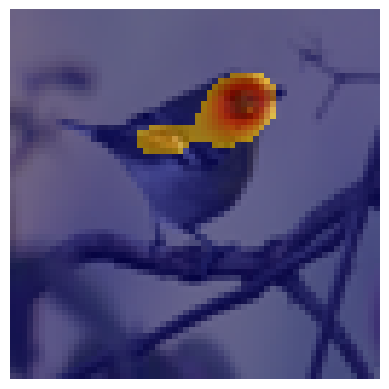

In [14]:
plt.figure()
plt.imshow(edit_image.resize((64, 64)), interpolation='none')
plt.imshow(edit_output.thresholded_mask[0, 0].cpu().numpy(), 'jet', interpolation='none', alpha=0.5)
plt.axis('off')
plt.show()

In [15]:
sae_feature_mask = F.resize(edit_output.thresholded_mask[0, 0].unsqueeze(0), (14, 14), interpolation=F.InterpolationMode.BICUBIC)
sae_feature_mask = sae_feature_mask.repeat(768, 1, 1)
sae_feature_mask.shape

torch.Size([768, 14, 14])

In [16]:
sae_feature_mask -= sae_feature_mask.min()
sae_feature_mask /= sae_feature_mask.max()

In [17]:
sae.activation = nn.ReLU()

with torch.no_grad():
    recon_features = classifier.forward_features_spatial(
        classifier.preprocess_tensor_image(recon).unsqueeze(0).cuda()
    )
    recon_features_pooled = (
        classifier.feature_extractor.forward_spatial_to_pooled(
            recon_features * sae_feature_mask.unsqueeze(0)
        )
    )
    recon_sae_feats = sae(recon_features_pooled)[1]
    
    edit_features = classifier.forward_features_spatial(
        classifier.preprocess_tensor_image(edit_image).unsqueeze(0).cuda()
    )
    edit_features_pooled = (
        classifier.feature_extractor.forward_spatial_to_pooled(
            edit_features * sae_feature_mask.unsqueeze(0)
        )
    )
    edit_sae_feats = sae(edit_features_pooled)[1]

In [18]:
diff_sae_feats = (edit_sae_feats - recon_sae_feats)[0]
top_sae_diff_feats = torch.argsort(diff_sae_feats.abs(), descending=True)
top_sae_diff_feats[:5]

tensor([ 15,   0,   4,  36, 102], device='cuda:0')

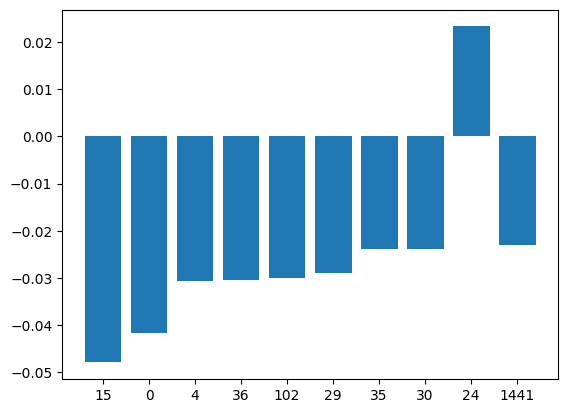

In [24]:
plt.figure()
plt.bar(
    [str(x) for x in top_sae_diff_feats[:10].detach().cpu().numpy()],
    diff_sae_feats[top_sae_diff_feats[:10]].detach().cpu().numpy()
)
plt.show()

In [ ]:
from slc.pipelines.sae_latent_edit import SAEFeatureLatentEditPipeline

sae_configs.verbose = True
sae_configs.gaussian_blur_sigma = 4
sae_configs.mask_threshold = 0.7
sae_configs.sparsity_lambda = 0.1
sae_configs.early_stop_threshold = 0.1
sae_configs.peturb_strength = 0.1
sae_configs.lr = 0.1
edit_pipeline = SAEFeatureLatentEditPipeline(classifier, vae, sae_configs, sae)

Creating Counterfactual:  13%|█▎        | 65/500 [00:12<01:26,  5.05it/s, class_loss=0, sparsity_loss=0.0908, predicted_class=0, src_conf=0.521, tgt_conf=0.5]        


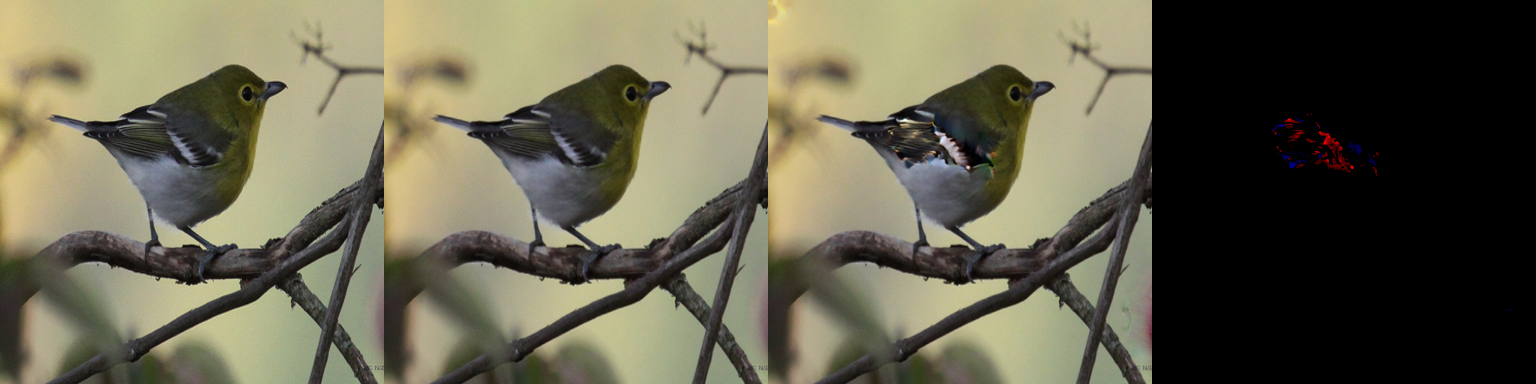

In [36]:
from diffusers.utils import make_image_grid

from slc.vis import create_diff_image
from slc.pipelines import EditPipelineOutput

increase = False
sae_feature = 15
edit_output: EditPipelineOutput = edit_pipeline(img, src_label=0 if increase else 1, tgt_label=sae_feature, is_binary=True)

recon = edit_output.recon_image.resize((384, 384))
edit_image = edit_output.edit_image.resize((384, 384))
diff_img = create_diff_image(edit_image, recon, threshold=0.2)

make_image_grid(
    [
        img.resize((384, 384)), 
        recon,
        edit_image,
        diff_img
    ],
    rows=1,
    cols=4
)